<a href="https://colab.research.google.com/github/abhinav7056/Celebal-Technolgies-Internship/blob/main/Week6_Abhinav_Garg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Build a deep learning model that can remove noise from images using an autoencoder on MNIST**

### 1. Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

###2. Loading Dataset

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


###3. Normalize and Reshape Data

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("Training shape:", x_train.shape)

Training shape: (60000, 28, 28, 1)


###4. Add Noise to Images

In [ ]:
noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(0.0, 1.0, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0.0, 1.0, x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

###5. Build Autoencoder Model

In [ ]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)

###6. Compile Model

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

###7. Train Model

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0811 - val_loss: 0.0803
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0808 - val_loss: 0.0800
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0806 - val_loss: 0.0798
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0803 - val_loss: 0.0796
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0802 - val_loss: 0.0795
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0800 - val_loss: 0.0792
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0798 - val_loss: 0.0793
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0797 - val_loss: 0.0790
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0796 - val_loss: 0.0789
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0795 - val_loss: 0.0788


###8. Predict Denoised Images

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

print("Min pixel:", decoded_imgs.min())
print("Max pixel:", decoded_imgs.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Min pixel: 2.0605578e-11
Max pixel: 0.9993388


###9. Visualization of Results

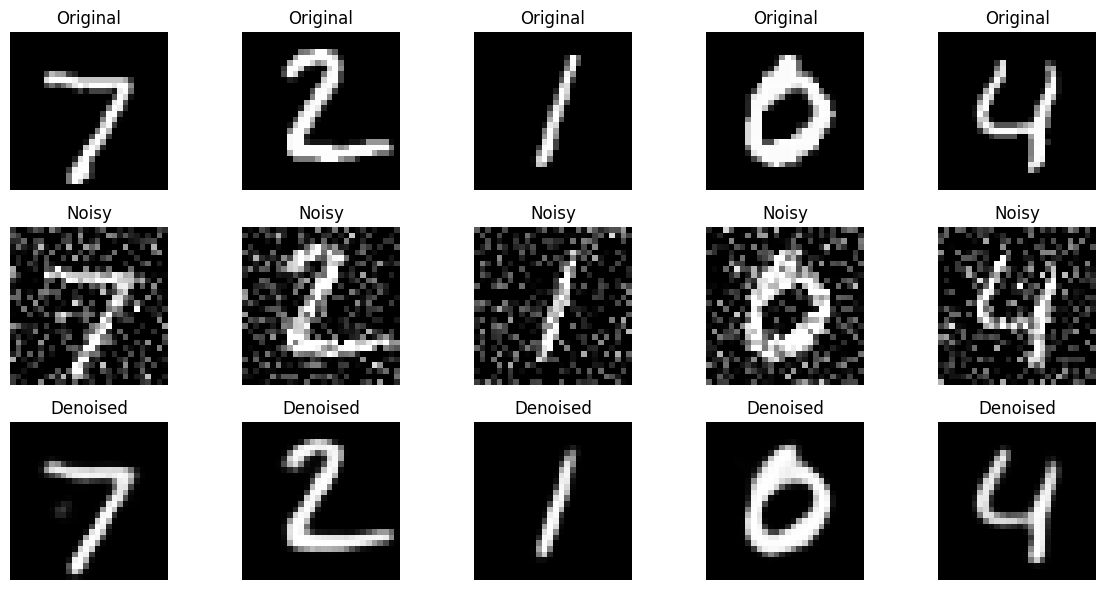

In [ ]:
n = 5
plt.figure(figsize=(12, 6))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

###10. Training Performance Graph

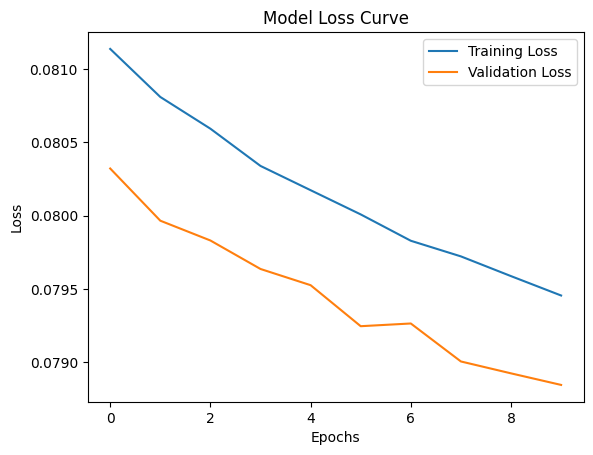

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Project Description
The objective of this project is to train a neural network capable of reconstructing clean images from noisy inputs. The workflow follows these key stages:
* Data Preparation: The MNIST dataset is loaded, normalized to a range of $[0, 1]$, and reshaped to include a channel dimension suitable for convolutional layers.
* Noise Injection: Synthetic noise is added to the clean images using a Gaussian distribution, and the values are clipped to maintain the valid $[0, 1]$ intensity range.
* Model Architecture: The model employs an Encoder-Decoder structure:
1. Encoder: Uses Conv2D layers paired with MaxPooling2D to progressively downsample the input, learning a compressed representation of the digits.
2. Decoder: Uses UpSampling2D layers to reconstruct the image to its original $28 \times 28$ dimensions, with the final output layer using a sigmoid activation to ensure pixel values remain in the $[0, 1]$ range.
* Training & Evaluation: The model is compiled using the adam optimizer and binary_crossentropy loss. It is trained over 10 epochs, effectively learning to map noisy digit patterns back to their original, clean counterparts.

###Conclusion
The autoencoder successfully demonstrates the ability to filter out Gaussian noise from the MNIST images. The visualization of the results shows a clear transition from noisy, degraded input to clean, recognizable digits in the "Denoised" output. Furthermore, the Model Loss Curve indicates that both training and validation losses are converging, confirming that the model has effectively learned the underlying structure of the handwritten digits without overfitting to the noise. This approach highlights the effectiveness of deep learning architectures in image restoration tasks.